# Final experiment series

Consolidated notebook with three experiment series targeted at proving the
value of the trim/extend edit head. All experiments seed methods with the
**RPC / pi_random init** (`RandomPathCombiningRouteGenerator`, matching
`benchmark_init_visualize.ipynb`). All numeric tables and figures are saved to
`artifacts/results/` with the `final_` prefix so this notebook's outputs
do not collide with the other notebooks.

* **§A. Cross-city benchmark across alpha** -- reproduces Holliday et al.
  Tables 3 (passenger perspective, `alpha = 1`) and 4 (operator
  perspective, `alpha = 0`), plus a balanced `alpha = 0.5` row, on Mandl +
  Mumford0..Mumford3. Methods compared: NSGA-II, SA, GA, HH, BCO
  (heuristic type-1 + type-2), NBCO (neural type-1 + type-2),
  Heuristic + trim/extend (type-1 + type-5 split 5+5), Extend/trim
  edit-only (all type-5), RL improvement only.

* **§B. Figure-5 ablation of the trim/extend head** -- 2x2 ablation on
  Mumford0: construction half in {type-1 trained, RPC (paper's
  pi_random)} crossed with edit half in {type-2 heuristic, trim/extend
  edit model}. Pareto figure C_p vs C_o across `alpha in [0, 1]`. The gap
  between the `type-1` and `RPC` curves at the same edit head measures
  what trained construction contributes; the gap between `type-2` and
  `trim/extend` at the same construction half measures what the trim
  head contributes.

* **§C. Trim-grace ablation on Mandl** -- for "Extend/trim edit-only BCO
  (all 10 type-5 bees)" we sweep `trim_grace_period` in `{0, 1, 3, 5,
  10}` with `worse_accept` ON, on Mandl. Quantifies the contribution of
  the trim-grace mechanism we added to `bee_colony.py`.

Edit-model weights (`EDIT_MODEL_WEIGHTS_PATH`) must exist on disk for any
method that uses `n_type5_bees > 0` (BCO Heuristic+trim/extend, Extend/
trim edit-only, the trim/extend variants in §B, and §C).

## 1. Imports + global config

In [1]:
from pathlib import Path
import math
import gc
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import os as _os, sys as _sys
_NB_DIR = _os.path.abspath(".")
if _NB_DIR not in _sys.path:
    _sys.path.insert(0, _NB_DIR)
import eval_lib
from eval_lib import *  # noqa: F401,F403
from eval_lib import plots as _plots, _run_baseline

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

FINAL_RESULTS_SUBDIR = "final"  # all save_table calls below use subdir=FINAL_RESULTS_SUBDIR
FINAL_RESULTS_DIR = RESULTS_DIR / FINAL_RESULTS_SUBDIR
FINAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("eval_lib OK; RESULTS_DIR =", RESULTS_DIR.relative_to(ROOT_DIR))
print(f"final outputs -> artifacts/results/{FINAL_RESULTS_SUBDIR}/")
print(f"EDIT_MODEL_WEIGHTS_PATH exists: {EDIT_MODEL_WEIGHTS_PATH.exists()}")
print(f"MODEL_WEIGHTS_PATH exists:      {MODEL_WEIGHTS_PATH.exists()}")
print(f"BENCHMARK_SPECS ({len(BENCHMARK_SPECS)} cities) and BCO_VARIANTS "
      f"({len(BCO_VARIANTS)} entries) in scope")

eval_lib OK; RESULTS_DIR = artifacts\results
final outputs -> artifacts/results/final/
EDIT_MODEL_WEIGHTS_PATH exists: True
MODEL_WEIGHTS_PATH exists:      True
BENCHMARK_SPECS (5 cities) and BCO_VARIANTS (6 entries) in scope


## 2. Section A: Cross-city benchmark across alpha

For every `(city, alpha)` pair we run every method from the same NX-
heuristic init under cost weights
`(demand_time_weight = alpha, route_time_weight = 1 - alpha,
median_connectivity_weight = 0)`. This sweeps the operator -> balanced ->
passenger trade-off the paper isolates as Tables 3 and 4. After the
sweep three display tables are built -- one per alpha value -- with
columns matching Holliday's: City, Method, C_p (ATT), C_o (RTT),
d_0, d_1, d_2, d_un, cost.

NSGA-II is multi-objective: its `_run_baseline` post-eval uses the same
alpha-weighted cost as everyone else, but its Pareto front is reduced
to the lowest-weighted-sum member via `reduce_pareto_front(output,
demand_weight=alpha, route_weight=1-alpha)`.

SA / GA / HH cost-function weights are hardcoded in
`_baseline_cfg_overrides` from `eval_lib.params.DEMAND/ROUTE/CONN_WEIGHT`;
we override them on the composed cfg via direct attribute assignment
before running.

In [2]:
ALPHA_GRID = [0.0, 0.5, 1.0]
ALPHA_LABELS = {0.0: "operator (alpha=0)",
                0.5: "balanced (alpha=0.5)",
                1.0: "passenger (alpha=1)"}

# Methods to compare. Names match the user spec exactly.
A_METHODS = [
    ("NSGA-II",                                    "nsgaii"),
    ("Simulated annealing",                        "sa"),
    ("Genetic algorithm",                          "ga"),
    ("Hyper-heuristics",                           "hh"),
    ("BCO",                                        "bco_variant:seeded_heuristic"),
    ("NBCO",                                       "bco_variant:seeded_neural"),
    ("Heuristic BCO Type 1 + trim/extend",         "bco_variant:heuristic_extend_trim_split_5_5"),
    ("BCO: Extend/trim edit-only BCO (all 10 bees)", "bco_variant:extend_trim_edit_only"),
    ("RL improvement only",                        "rl_only"),
    (f"{benchmark_init_label()} (initial)",        "initial"),
]

BCO_VARIANT_LOOKUP = {v["key"]: v for v in BCO_VARIANTS}

A_CITIES = ["Mandl", "Mumford0", "Mumford1", "Mumford2", "Mumford3"]
A_SEED = 0  # single seed sweep -- bump if you need confidence intervals
REUSE_EXISTING_A_SWEEP = True
# Full experiment budgets: keep these tied to eval_lib defaults so the
# notebook cannot silently drift back into a reduced test mode.
SECTION_A_NSGAII_N_ITER   = NSGAII_N_ITERATIONS
SECTION_A_NSGAII_POP_SIZE = NSGAII_POP_SIZE
SECTION_A_SA_N_ITER       = SA_N_ITERATIONS
SECTION_A_GA_N_ITER       = GA_N_ITERATIONS
SECTION_A_HH_N_ITER       = HH_N_ITERATIONS
SECTION_A_BCO_N_ITER      = BCO_N_ITERATIONS

# Patience-based early stopping. Per-algo defaults tuned to each
# algorithm's noise profile (SA/HH stochastic-accept -> long patience;
# GA/BCO elitist best-cost -> shorter patience). Set patience=None to
# disable early stopping while keeping the same iteration budgets.
SECTION_A_SA_EARLY_STOP_PATIENCE  = 3000   # ~15% of 20000 default
SECTION_A_GA_EARLY_STOP_PATIENCE  = 40     # ~20% of 200 default
SECTION_A_HH_EARLY_STOP_PATIENCE  = 4000   # ~20% of 20000 default
SECTION_A_BCO_EARLY_STOP_PATIENCE = 25     # ~12% of 200 default
SECTION_A_EARLY_STOP_MIN_DELTA    = 1e-4   # cost units (~1e-4 of cost~1.0)
print()
print("[full experiment mode] iteration counts:")
print(f"  NSGA-II: n_iter={SECTION_A_NSGAII_N_ITER}, pop_size={SECTION_A_NSGAII_POP_SIZE}")
print(f"  SA:      n_iter={SECTION_A_SA_N_ITER}")
print(f"  GA:      n_iter={SECTION_A_GA_N_ITER}")
print(f"  HH:      n_iter={SECTION_A_HH_N_ITER}")
print(f"  BCO:     n_iter={SECTION_A_BCO_N_ITER}")
print(f"[early-stop] patience: SA={SECTION_A_SA_EARLY_STOP_PATIENCE}, "
      f"GA={SECTION_A_GA_EARLY_STOP_PATIENCE}, "
      f"HH={SECTION_A_HH_EARLY_STOP_PATIENCE}, "
      f"BCO={SECTION_A_BCO_EARLY_STOP_PATIENCE}, "
      f"min_delta={SECTION_A_EARLY_STOP_MIN_DELTA}")
print()
# Full final runs should fail fast if weights are missing rather than
# writing partial tables with skipped neural/edit-model rows.
REQUIRE_MODEL_WEIGHTS = True
REQUIRE_EDIT_MODEL_WEIGHTS = True
if REQUIRE_MODEL_WEIGHTS and not MODEL_WEIGHTS_PATH.exists():
    raise FileNotFoundError(f"MODEL_WEIGHTS_PATH missing: {MODEL_WEIGHTS_PATH}")
if REQUIRE_EDIT_MODEL_WEIGHTS and not EDIT_MODEL_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"EDIT_MODEL_WEIGHTS_PATH missing: {EDIT_MODEL_WEIGHTS_PATH}")
print("MODEL_WEIGHTS_PATH OK; neural-construction methods runnable.")
print("EDIT_MODEL_WEIGHTS_PATH OK; trim/extend methods runnable.")

print(f"Section A matrix: {len(A_CITIES)} cities x {len(ALPHA_GRID)} alphas "
      f"x {len(A_METHODS)} methods = "
      f"{len(A_CITIES) * len(ALPHA_GRID) * len(A_METHODS)} runs")


[full experiment mode] iteration counts:
  NSGA-II: n_iter=1000, pop_size=200
  SA:      n_iter=20000
  GA:      n_iter=200
  HH:      n_iter=20000
  BCO:     n_iter=200
[early-stop] patience: SA=3000, GA=40, HH=4000, BCO=25, min_delta=0.0001

MODEL_WEIGHTS_PATH OK; neural-construction methods runnable.
EDIT_MODEL_WEIGHTS_PATH OK; trim/extend methods runnable.
Section A matrix: 5 cities x 3 alphas x 10 methods = 150 runs


In [3]:
def _set_cfg_weights(cfg, alpha):
    """Override (demand, route, conn) cost weights in a composed cfg
    in-place. Used for SA/GA/HH/NSGA-II where the builder hardcodes
    DEMAND/ROUTE/CONN_WEIGHT defaults from eval_lib.params."""
    cfg.experiment.cost_function.kwargs.demand_time_weight = float(alpha)
    cfg.experiment.cost_function.kwargs.route_time_weight = float(1.0 - alpha)
    cfg.experiment.cost_function.kwargs.median_connectivity_weight = 0.0
    return cfg


def _alpha_weights_dict(alpha):
    return {"demand_time_weight": float(alpha),
            "route_time_weight": float(1.0 - alpha),
            "median_connectivity_weight": 0.0}


def _float_key(value):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return None
    if not np.isfinite(value):
        return None
    return round(value, 10)


def _finite_number(value):
    try:
        return bool(np.isfinite(float(value)))
    except (TypeError, ValueError):
        return False


def _int_key(value):
    try:
        return int(value)
    except (TypeError, ValueError):
        return None


def _mutation_summary_fields(mutation_stats):
    """Flatten BCO mutation counters for tables.

    `accepted` includes cost-improving accepts, worse accepts, and trim-grace
    forced accepts. `rejected` is attempted - accepted."""
    if not mutation_stats:
        return None
    attempted = mutation_stat_bucket(mutation_stats, "attempted")
    accepted = mutation_stat_bucket(mutation_stats, "accepted")
    worse_accepted = mutation_stat_bucket(mutation_stats, "worse_accepted")
    selection = selection_stat_bucket(mutation_stats)
    fields = {}
    attempted_total = int(sum(attempted.values()))
    accepted_total = int(sum(accepted.values()))
    worse_total = int(sum(worse_accepted.values()))
    rejected_total = max(attempted_total - accepted_total, 0)
    fields.update({
        "attempted_total": attempted_total,
        "accepted_total": accepted_total,
        "rejected_total": rejected_total,
        "worse_accepted_total": worse_total,
        "acceptance_rate": (accepted_total / attempted_total
                            if attempted_total else float("nan")),
        "trim_grace_forced_accepts": selection.get("trim_grace_forced_accepts", 0),
        "trim_grace_protected": selection.get("trim_grace_protected", 0),
    })
    for type_name in MUTATION_TYPE_KEYS:
        slug = mutation_slug(type_name)
        fields[f"attempted_{slug}"] = int(attempted[type_name])
        fields[f"accepted_{slug}"] = int(accepted[type_name])
        fields[f"rejected_{slug}"] = max(
            int(attempted[type_name]) - int(accepted[type_name]), 0)
    return fields


def _mutation_row(section, city, alpha, method, mutation_stats, runtime_s):
    fields = _mutation_summary_fields(mutation_stats)
    if fields is None:
        return None
    return {"section": section, "city": city, "alpha": alpha,
            "method": method, "runtime_s": runtime_s, **fields}


def _history_rows_from_dict(histories, section="A"):
    rows = []
    for (city, alpha, method), history in histories.items():
        if history is None:
            continue
        arr = np.asarray(history, dtype=float).reshape(-1)
        if arr.size == 0:
            continue
        first = arr[0]
        run_id = safe_run_name(f"{city}_a{alpha}_{method}")
        for iteration, cost in enumerate(arr):
            rows.append({
                "section": section,
                "city": city,
                "alpha": alpha,
                "method": method,
                "run_id": run_id,
                "iteration": iteration,
                "cost": float(cost),
                "normalized_cost": (float(cost) / float(first)
                                    if first != 0 else float("nan")),
            })
    return rows


def _method_needs_edit_model(method_kind):
    """True if running this method requires EDIT_MODEL_WEIGHTS_PATH on disk
    (i.e. any BCO variant with n_type5/6/7 > 0 or the rl_only path).
    Used to gracefully skip these methods when the edit-model has not been
    trained locally yet, instead of raising FileNotFoundError mid-sweep."""
    if method_kind == "rl_only":
        return True
    if method_kind.startswith("bco_variant:"):
        key = method_kind.split(":", 1)[1]
        v = BCO_VARIANT_LOOKUP[key]
        return (int(v.get("n_type5_bees", 0))
                + int(v.get("n_type6_bees", 0))
                + int(v.get("n_type7_bees", 0))) > 0
    return False


def _run_one(city, alpha, method_label, method_kind, spec, tensors, init_routes):
    """Run one (city, alpha, method) combo; return a flat row dict.

    Raises FileNotFoundError early (with a clear message) when the method
    requires the trained edit model but `EDIT_MODEL_WEIGHTS_PATH` is missing
    locally -- the outer sweep loop catches this and records a skip row."""
    if _method_needs_edit_model(method_kind) and not EDIT_MODEL_WEIGHTS_PATH.exists():
        raise FileNotFoundError(
            f"edit-model weights missing at {EDIT_MODEL_WEIGHTS_PATH} -- "
            f"method '{method_label}' requires the trained edit policy "
            f"(train via lc_improvement_training.ipynb or copy the .pt over).")
    weights = _alpha_weights_dict(alpha)
    cost_history = None   # overridden in sa/ga/hh/bco branches
    mutation_stats = None  # BCO-only; flattened later for mutation tables
    nr, mn, mx = spec["n_routes"], spec["min_route_len"], spec["max_route_len"]
    run_scope = f"final_a_{city}_a{alpha:.1f}_"

    if method_kind == "initial":
        cfg = build_sa_cfg(f"{run_scope}initial", nr, mn, mx)
        _set_cfg_weights(cfg, alpha)
        _, metrics, _, routes = _run_baseline(
            None, cfg, init_routes, f"{run_scope}initial_", {}, tensors=tensors)
    elif method_kind == "sa":
        cfg = build_sa_cfg(f"{run_scope}sa", nr, mn, mx,
                           n_iterations=SECTION_A_SA_N_ITER,
                           early_stop_patience=SECTION_A_SA_EARLY_STOP_PATIENCE,
                           early_stop_min_delta=SECTION_A_EARLY_STOP_MIN_DELTA)
        _set_cfg_weights(cfg, alpha)
        _, metrics, _, routes, _histories = run_sa(
            cfg, init_routes, tensors=tensors,
            run_name_scope=run_scope, return_history=True)
        if _histories:
            _h = _histories[0]
            cost_history = _h[0].cpu().numpy() if hasattr(_h, "cpu") else _h
    elif method_kind == "ga":
        cfg = build_ga_cfg(f"{run_scope}ga", nr, mn, mx,
                           n_iterations=SECTION_A_GA_N_ITER,
                           early_stop_patience=SECTION_A_GA_EARLY_STOP_PATIENCE,
                           early_stop_min_delta=SECTION_A_EARLY_STOP_MIN_DELTA)
        _set_cfg_weights(cfg, alpha)
        _, metrics, _, routes, _histories = run_ga(
            cfg, init_routes, tensors=tensors,
            run_name_scope=run_scope, return_history=True)
        if _histories:
            _h = _histories[0]
            cost_history = _h[0].cpu().numpy() if hasattr(_h, "cpu") else _h
    elif method_kind == "hh":
        cfg = build_hh_cfg(f"{run_scope}hh", nr, mn, mx,
                           n_iterations=SECTION_A_HH_N_ITER,
                           early_stop_patience=SECTION_A_HH_EARLY_STOP_PATIENCE,
                           early_stop_min_delta=SECTION_A_EARLY_STOP_MIN_DELTA)
        _set_cfg_weights(cfg, alpha)
        _, metrics, _, routes, _histories = run_hh(
            cfg, init_routes, tensors=tensors,
            run_name_scope=run_scope, return_history=True)
        if _histories:
            _h = _histories[0]
            cost_history = _h[0].cpu().numpy() if hasattr(_h, "cpu") else _h
    elif method_kind == "nsgaii":
        # NSGA-II uses MultiObjectiveCostModule (cfg/cost_function/multi.yaml)
        # which has no demand_time_weight/route_time_weight in its kwargs --
        # the multi-objective Pareto front is alpha-independent. We do NOT
        # call _set_cfg_weights on the nsgaii cfg (would fail with
        # ConfigAttributeError: Key 'demand_time_weight' is not in struct).
        # Alpha weighting is applied OUTSIDE via reduce_pareto_front below,
        # and the post-eval cfg (`build_sa_cfg`) is `mine` cost so its
        # weights ARE set via _set_cfg_weights as usual.
        cfg = build_nsgaii_cfg(f"{run_scope}nsgaii", nr, mn, mx, n_iterations=SECTION_A_NSGAII_N_ITER, pop_size=SECTION_A_NSGAII_POP_SIZE)
        _, output = run_nsgaii(cfg, tensors=tensors, init_routes=init_routes,
                                run_name_scope=run_scope)
        best = reduce_pareto_front(output, weights["demand_time_weight"],
                                    weights["route_time_weight"])
        picked = best["routes"]
        if picked.ndim == 2: picked = picked[None]
        eval_cfg = build_sa_cfg(f"{run_scope}nsgaii_eval", nr, mn, mx)
        _set_cfg_weights(eval_cfg, alpha)
        _, metrics, _, routes = _run_baseline(
            None, eval_cfg, picked, f"{run_scope}nsgaii_eval_", {},
            tensors=tensors)
    elif method_kind == "rl_only":
        _, metrics, _, routes, *_rest = run_rl_improvement(
            init_routes, run_name=f"{run_scope}rl_only",
            n_routes=nr, min_route_len=mn, max_route_len=mx,
            tensors=tensors, weights=weights)
    elif method_kind.startswith("bco_variant:"):
        key = method_kind.split(":", 1)[1]
        variant = BCO_VARIANT_LOOKUP[key]
        cfg = build_bco_cfg(
            run_name=f"{run_scope}{variant['run_name']}",
            n_routes=nr, min_route_len=mn, max_route_len=mx,
            use_neural_bees=variant["use_neural_bees"],
            n_type1_bees=variant["n_type1_bees"],
            n_type2_bees=variant["n_type2_bees"],
            n_type4_bees=variant["n_type4_bees"],
            n_type5_bees=variant.get("n_type5_bees", 0),
            n_type6_bees=variant.get("n_type6_bees", 0),
            n_type7_bees=variant.get("n_type7_bees", 0),
            early_stop_patience=SECTION_A_BCO_EARLY_STOP_PATIENCE,
            early_stop_min_delta=SECTION_A_EARLY_STOP_MIN_DELTA,
            **weights)
        cfg.experiment.seed = A_SEED
        cfg.n_iterations = SECTION_A_BCO_N_ITER
        _ch_out = {}
        _mc_out = {}
        _, metrics, _, routes, _mc = run_bco(
            cfg, init_routes, mutation_counts_out=_mc_out,
            tensors=tensors, run_name_scope=run_scope,
            cost_history_out=_ch_out)
        mutation_stats = _mc
        _h = _ch_out.get("history")
        if _h is not None:
            cost_history = _h[0].cpu().numpy() if hasattr(_h, "cpu") else _h
    else:
        raise ValueError(f"Unknown method kind: {method_kind}")

    # cost_history (when captured) is shape (iters_completed + 1,):
    # column 0 is the initial cost, then one per iteration.
    _expected_iters_by_kind = {
        "sa":  SECTION_A_SA_N_ITER,
        "ga":  SECTION_A_GA_N_ITER,
        "hh":  SECTION_A_HH_N_ITER,
    }
    if method_kind.startswith("bco_variant:"):
        _expected_iters = SECTION_A_BCO_N_ITER
    else:
        _expected_iters = _expected_iters_by_kind.get(method_kind)
    if cost_history is not None and _expected_iters is not None:
        _iters_completed = int(len(cost_history) - 1)
        _early_stopped = _iters_completed < int(_expected_iters)
    else:
        _iters_completed = None
        _early_stopped = False
    row = {"city": city, "alpha": alpha, "method": method_label,
           "ATT": float(metric_value(metrics, "ATT")),
           "RTT": float(metric_value(metrics, "RTT")),
           "d_0": float(metric_value(metrics, "$d_0$")),
           "d_1": float(metric_value(metrics, "$d_1$")),
           "d_2": float(metric_value(metrics, "$d_2$")),
           "d_un": float(metric_value(metrics, "$d_{un}$")),
           "cost": float(metric_value(metrics, "cost")),
           "iters_completed": _iters_completed,
           "iters_expected": (int(_expected_iters)
                              if _expected_iters is not None else None),
           "early_stopped": bool(_early_stopped)}
    return row, routes, cost_history, mutation_stats

### Section A init-routes preview

Before launching the benchmark sweep, render the initial route network that
every method in `A_METHODS` will start from for each city in `A_CITIES`.
Both BCO variants, the heuristic baselines (SA / GA / HH / NSGA-II) and the
RL-improvement-only path all use this exact same `init_routes` tensor as
their starting point, so the figure below is the "frame zero" of every
algorithm in Section A.

`benchmark_init_label()` reflects the current `BENCHMARK_INIT_MODE`
(NX-heuristic or LC-sampled); changing the knob and rerunning this cell
shows the new starting point before triggering the sweep.

D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:313: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


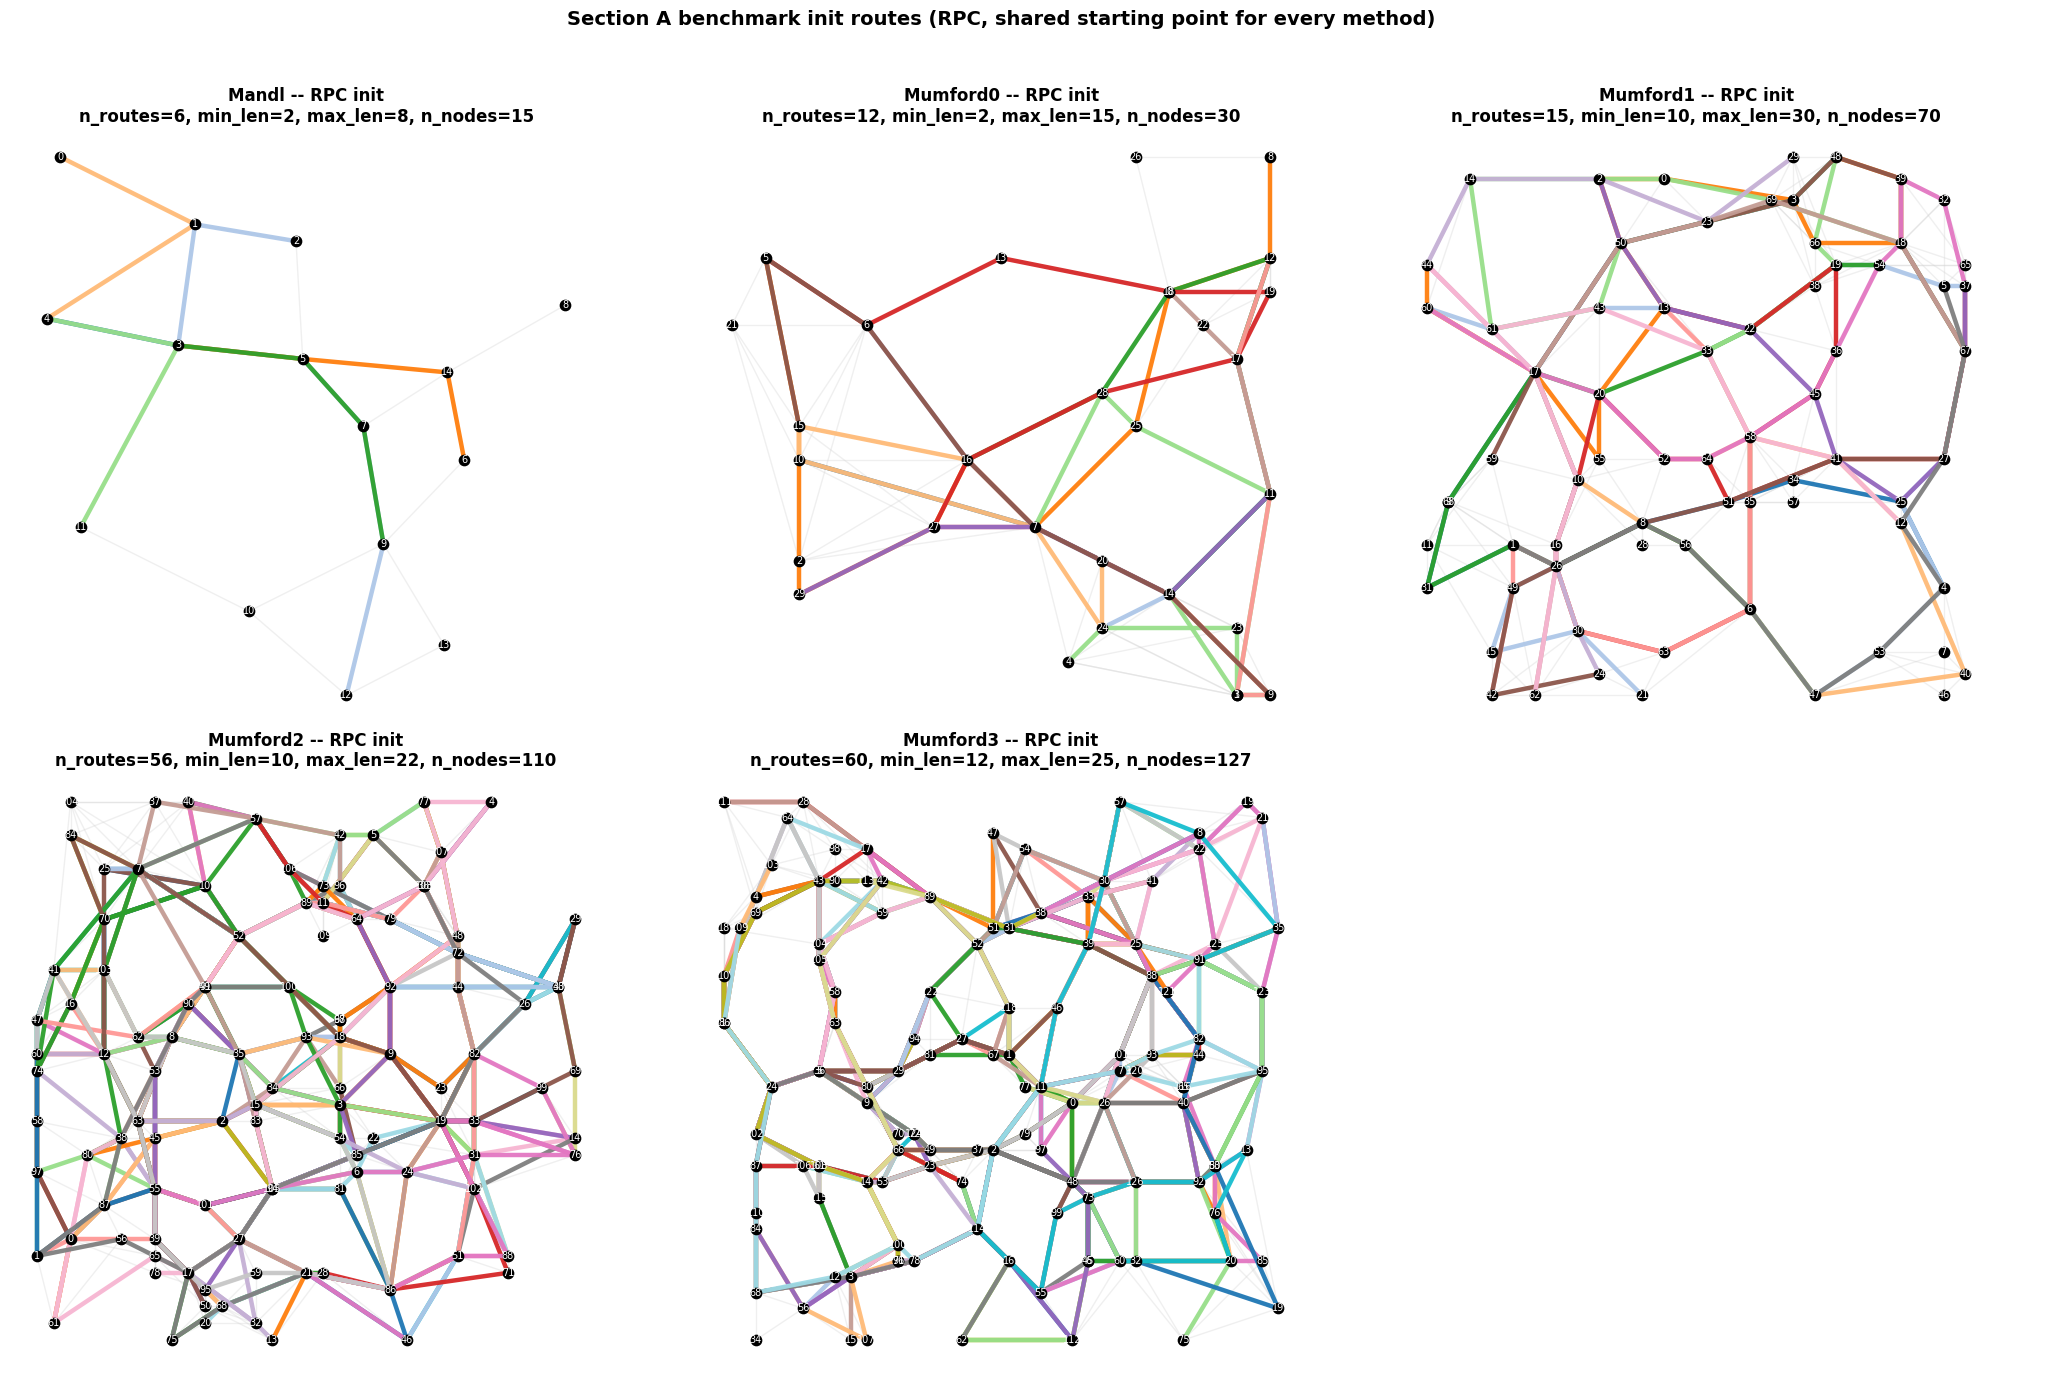

In [4]:
_city_to_spec_viz = {s["city"]: s for s in BENCHMARK_SPECS}
_n_cities = len(A_CITIES)
_ncols = min(_n_cities, 3)
_nrows = (_n_cities + _ncols - 1) // _ncols
_fig, _axes = plt.subplots(_nrows, _ncols,
                            figsize=(7 * _ncols, 7 * _nrows), squeeze=False)
for _i, _city in enumerate(A_CITIES):
    _spec_viz = _city_to_spec_viz[_city]
    _tensors_viz, _init_routes_viz = load_benchmark_graph(_spec_viz)
    _ax = _axes[_i // _ncols][_i % _ncols]
    _nr_v = _spec_viz["n_routes"]
    _mn_v = _spec_viz["min_route_len"]
    _mx_v = _spec_viz["max_route_len"]
    _nn_v = _tensors_viz["node_locs"].shape[0]
    _plots.plot_plain_route_set(
        _ax, _init_routes_viz,
        _tensors_viz["node_locs"], _tensors_viz["street_adj"],
        title=f"{_city} -- {benchmark_init_label()} init",
        subtitle=f"n_routes={_nr_v}, min_len={_mn_v}, "
                 f"max_len={_mx_v}, n_nodes={_nn_v}",
        palette="tab20",
        with_overlap_curves=False)
# Hide unused subplot slots (when n_cities < nrows*ncols).
for _j in range(_n_cities, _nrows * _ncols):
    _axes[_j // _ncols][_j % _ncols].axis("off")
_fig.suptitle(
    f"Section A benchmark init routes ({benchmark_init_label()}, "
    f"shared starting point for every method)",
    fontsize=14, fontweight="bold")
_fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In [5]:
_existing_a_rows = globals().get("final_a_rows", [])
_existing_a_histories = globals().get("final_a_histories", {})
_expected_a_keys = {
    (city, _float_key(alpha), label)
    for city in A_CITIES for alpha in ALPHA_GRID for label, _ in A_METHODS
}
_existing_a_keys = {
    (row.get("city"), _float_key(row.get("alpha")), row.get("method"))
    for row in _existing_a_rows
}
_existing_a_rows_ok = (
    len(_existing_a_rows) == len(_expected_a_keys)
    and _existing_a_keys == _expected_a_keys
    and all(_finite_number(row.get("cost")) for row in _existing_a_rows)
)
_can_reuse_a_sweep = (
    bool(globals().get("REUSE_EXISTING_A_SWEEP", False))
    and bool(_existing_a_rows)
    and _existing_a_rows_ok
    and globals().get("final_a_init_mode") == globals().get("BENCHMARK_INIT_MODE")
    and any(h is not None for h in _existing_a_histories.values())
)
if _can_reuse_a_sweep:
    final_a_rows = _existing_a_rows
    final_a_histories = _existing_a_histories
    final_a_mutation_rows = globals().get("final_a_mutation_rows", [])
    print("Reusing existing final_a_rows; "
          "set REUSE_EXISTING_A_SWEEP=False to rerun.")
else:
    if bool(globals().get("REUSE_EXISTING_A_SWEEP", False)) and _existing_a_rows:
        print("Existing final_a_rows do not match the current init/history "
              "requirements or include failed rows; rerunning Section A.")
    final_a_rows = []
    final_a_histories = {}   # (city, alpha, method) -> cost-per-iter or None
    final_a_mutation_rows = []
    final_a_init_mode = BENCHMARK_INIT_MODE
    city_to_spec_a = {s["city"]: s for s in BENCHMARK_SPECS}
    for city in A_CITIES:
        spec = city_to_spec_a[city]
        tensors, init_routes = load_benchmark_graph(spec)
        for alpha in ALPHA_GRID:
            for label, kind in A_METHODS:
                print(f"  [{city} | alpha={alpha} | {label}] running...")
                run_start = time.perf_counter()
                try:
                    row, _routes, _history, _mutation_stats = _run_one(
                        city, alpha, label, kind, spec, tensors, init_routes)
                    row["runtime_s"] = time.perf_counter() - run_start
                    row["init_mode"] = BENCHMARK_INIT_MODE
                    row["init_method"] = benchmark_init_label()
                    final_a_rows.append(row)
                    final_a_histories[(city, alpha, label)] = _history
                    _mut_row = _mutation_row(
                        "A", city, alpha, label, _mutation_stats,
                        row["runtime_s"])
                    if _mut_row is not None:
                        final_a_mutation_rows.append(_mut_row)
                    _es_flag = (
                        f" [early-stop @ {row['iters_completed']}/{row['iters_expected']} iters]"
                        if row.get("early_stopped") else "")
                    print(f"    -> cost={row['cost']:.4f}, ATT={row['ATT']:.2f}, "
                          f"RTT={row['RTT']:.2f}, time={row['runtime_s']:.1f}s{_es_flag}")
                except FileNotFoundError as exc:
                    print(f"    SKIP: {exc}")
                except Exception as exc:
                    print(f"    FAILED: {exc!r}")
                    runtime_s = time.perf_counter() - run_start
                    final_a_rows.append({"city": city, "alpha": alpha,
                                         "method": label,
                                         "ATT": float("nan"), "RTT": float("nan"),
                                         "d_0": float("nan"), "d_1": float("nan"),
                                         "d_2": float("nan"), "d_un": float("nan"),
                                         "cost": float("nan"),
                                         "runtime_s": runtime_s,
                                         "init_mode": BENCHMARK_INIT_MODE,
                                         "init_method": benchmark_init_label()})
                finally:
                    gc.collect()
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()

if "final_a_mutation_rows" not in globals():
    final_a_mutation_rows = []
if "final_a_histories" not in globals():
    final_a_histories = {}

final_a_df = pd.DataFrame(final_a_rows)
final_a_history_df = pd.DataFrame(_history_rows_from_dict(final_a_histories))
final_a_mutation_df = pd.DataFrame(final_a_mutation_rows)
save_table(final_a_df, "benchmark_alpha_rows", subdir=FINAL_RESULTS_SUBDIR)
if not final_a_history_df.empty:
    save_table(final_a_history_df, "benchmark_cost_history_rows",
               subdir=FINAL_RESULTS_SUBDIR)
if not final_a_mutation_df.empty:
    save_table(final_a_mutation_df, "benchmark_mutation_acceptance_rows",
               subdir=FINAL_RESULTS_SUBDIR)
print(f"\n{len(final_a_df)} rows total")
display(final_a_df.head(10).round(3))

  [Mandl | alpha=0.0 | NSGA-II] running...


100%|██████████| 800/800 [00:02<00:00, 299.43it/s]
100%|██████████| 24.00/24[00:05<00:00]
 62%|██████▏   | 621/1000 [12:16<07:29,  1.19s/it]


KeyboardInterrupt: 

### 3. Per-alpha display tables (Holliday Tables 3 + 4 shape)

For each `alpha` value we pivot the rows into a `City x Method` table
with the headline metrics (`C_p`, `C_o`, `d_0`, `d_1`, `d_2`, `d_un`).
Saved per-alpha as
`artifacts/results/final_benchmark_alpha_<alpha>.csv`.

In [ ]:
METRIC_COLS_ALPHA = ["ATT", "RTT", "d_0", "d_1", "d_2", "d_un", "cost", "runtime_s"]

for alpha in ALPHA_GRID:
    alpha_df = final_a_df[final_a_df["alpha"] == alpha].copy()
    if alpha_df.empty:
        continue
    print(f"\n========== alpha = {alpha} ({ALPHA_LABELS[alpha]}) ==========")
    show_cols = [c for c in (["city", "method"] + METRIC_COLS_ALPHA)
                 if c in alpha_df.columns]
    out = alpha_df[show_cols].reset_index(drop=True).round(3)
    save_table(out, f"benchmark_alpha_{alpha:.1f}", subdir=FINAL_RESULTS_SUBDIR)
    display(out)

NameError: name 'final_a_df' is not defined

### Section A runtime summary

`runtime_s` is measured around each method run and saved both in the raw
benchmark rows and in dedicated runtime tables.

In [ ]:
if "runtime_s" not in final_a_df.columns:
    print("No runtime_s column yet; rerun the Section A sweep cell.")
else:
    final_a_runtime_rows = final_a_df[["city", "alpha", "method", "runtime_s"]].copy()
    save_table(final_a_runtime_rows, "benchmark_runtime_rows",
               subdir=FINAL_RESULTS_SUBDIR)
    final_a_runtime_summary = (
        final_a_runtime_rows
        .groupby("method", as_index=False)["runtime_s"]
        .agg(mean_runtime_s="mean", std_runtime_s="std",
             min_runtime_s="min", max_runtime_s="max",
             total_runtime_s="sum", n_runs="count")
        .sort_values("mean_runtime_s")
    )
    save_table(final_a_runtime_summary, "benchmark_runtime_summary",
               subdir=FINAL_RESULTS_SUBDIR)
    display(final_a_runtime_summary.round(3))

### Section A accepted vs rejected BCO mutations

BCO exposes mutation counters, so this comparison covers BCO-family rows.
`rejected_total = attempted_total - accepted_total`; worse accepts and
trim-grace forced accepts are included in accepted totals and also shown
as separate columns where present.

In [ ]:
if final_a_mutation_df.empty:
    print("No BCO mutation stats captured yet; rerun the Section A sweep cell.")
else:
    save_table(final_a_mutation_df, "benchmark_mutation_acceptance_rows",
               subdir=FINAL_RESULTS_SUBDIR)
    final_a_mutation_summary = (
        final_a_mutation_df
        .groupby("method", as_index=False)
        .agg(attempted_total=("attempted_total", "sum"),
             accepted_total=("accepted_total", "sum"),
             rejected_total=("rejected_total", "sum"),
             worse_accepted_total=("worse_accepted_total", "sum"),
             trim_grace_forced_accepts=("trim_grace_forced_accepts", "sum"),
             runtime_s=("runtime_s", "mean"),
             n_runs=("method", "count"))
    )
    final_a_mutation_summary["acceptance_rate"] = (
        final_a_mutation_summary["accepted_total"] /
        final_a_mutation_summary["attempted_total"].replace(0, np.nan)
    )
    final_a_mutation_summary = final_a_mutation_summary.sort_values(
        ["acceptance_rate", "accepted_total"], ascending=[False, False])
    save_table(final_a_mutation_summary, "benchmark_mutation_acceptance_summary",
               subdir=FINAL_RESULTS_SUBDIR)
    display(final_a_mutation_summary.round(3))

    plot_df = final_a_mutation_summary.sort_values("attempted_total", ascending=False)
    xs = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(xs, plot_df["accepted_total"], label="accepted", color="tab:green", alpha=0.85)
    ax.bar(xs, plot_df["rejected_total"], bottom=plot_df["accepted_total"],
           label="rejected", color="tab:gray", alpha=0.65)
    ax.set_xticks(xs)
    ax.set_xticklabels(plot_df["method"], rotation=25, ha="right")
    ax.set_ylabel("mutation count")
    ax.set_title("Section A BCO mutation acceptance")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

### Section A history files and visualisation: cost-vs-iteration

Per-iteration cost curves for algorithms that expose cost_history (SA, GA,
HH, all BCO variants). NSGA-II, LC, RL-only, and the initial-network row
do not expose a comparable per-iteration trace and are skipped.

The long-form history table is saved as
`artifacts/results/final/benchmark_cost_history_rows.csv`.

The cell below also saves one PNG per method to
`artifacts/results/final/history_figures/history_<method>.png`, then saves
one combined comparison figure as `history_summary.png`.

For final runs, convergence figures use the same library-default
iteration budgets configured in the `SECTION_A_*_N_ITER` knobs.

In [ ]:
import numpy as _np_for_hist

# window=1 -> raw curves; window>1 applies a centred rolling mean for plots.
# Captured histories and saved CSV values stay raw.
HISTORY_SMOOTH_WINDOW = 1
HISTORY_FIGURE_DIR = FINAL_RESULTS_DIR / "history_figures"
HISTORY_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def _smooth(arr, window):
    if window is None or window <= 1 or len(arr) <= window:
        return arr
    kernel = _np_for_hist.ones(window, dtype=float) / float(window)
    smoothed = _np_for_hist.convolve(arr, kernel, mode="valid")
    pad_left = (window - 1) // 2
    pad_right = window - 1 - pad_left
    return _np_for_hist.concatenate([
        _np_for_hist.full(pad_left, smoothed[0]),
        smoothed,
        _np_for_hist.full(pad_right, smoothed[-1]),
    ])


def _history_frame_from_memory():
    if "final_a_history_df" in globals() and not final_a_history_df.empty:
        return final_a_history_df.copy()
    history_csv_path = FINAL_RESULTS_DIR / "benchmark_cost_history_rows.csv"
    if history_csv_path.exists():
        print(f"Loading existing history CSV -> {history_csv_path}")
        return pd.read_csv(history_csv_path)
    if "final_a_histories" not in globals():
        return pd.DataFrame()
    return pd.DataFrame(_history_rows_from_dict(final_a_histories))


def _method_history_stack(history_df, method, value_col):
    curves = []
    labels = []
    method_df = history_df[history_df["method"] == method]
    for (city, alpha, run_id), group in method_df.groupby(["city", "alpha", "run_id"]):
        arr = group.sort_values("iteration")[value_col].to_numpy(dtype=float)
        arr = arr[_np_for_hist.isfinite(arr)]
        if arr.size == 0:
            continue
        curves.append(arr)
        labels.append(f"{city}, alpha={alpha}")
    if not curves:
        return None, labels
    max_len = max(len(curve) for curve in curves)
    aligned = []
    for arr in curves:
        if len(arr) < max_len:
            arr = _np_for_hist.concatenate(
                [arr, _np_for_hist.full(max_len - len(arr), arr[-1])])
        aligned.append(_smooth(arr, HISTORY_SMOOTH_WINDOW))
    return _np_for_hist.stack(aligned), labels


def _save_history_figure(fig, file_stem):
    path = HISTORY_FIGURE_DIR / f"{safe_run_name(file_stem)}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print(f"[results] figure -> {path}")
    return path


def _plot_method_history(history_df, method):
    fig, ax = plt.subplots(figsize=(10, 5))
    stack, labels = _method_history_stack(history_df, method, "cost")
    if stack is None:
        ax.text(0.5, 0.5, "no history", ha="center", va="center")
        ax.set_axis_off()
    else:
        xs = _np_for_hist.arange(stack.shape[1])
        show_run_labels = len(labels) <= 8
        for arr, label in zip(stack, labels):
            ax.plot(xs, arr, color="tab:blue", alpha=0.22,
                    linewidth=0.8, label=label if show_run_labels else None)
        ax.plot(xs, stack.mean(axis=0), color="black", linewidth=2.2,
                label="mean")
        ax.set_xlabel("iteration")
        ax.set_ylabel("cost")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, loc="best")
    title = f"Section A history: {method}"
    if HISTORY_SMOOTH_WINDOW > 1:
        title += f" (rolling mean, window={HISTORY_SMOOTH_WINDOW})"
    ax.set_title(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    _save_history_figure(fig, f"history_{method}")
    plt.show()


def _plot_summary_history(history_df, methods):
    fig, ax = plt.subplots(figsize=(11, 6))
    cmap = plt.get_cmap("tab10")
    for i, method in enumerate(methods):
        stack, _ = _method_history_stack(history_df, method, "cost")
        if stack is None:
            continue
        xs = _np_for_hist.arange(stack.shape[1])
        ax.plot(xs, stack.mean(axis=0), color=cmap(i % 10),
                linewidth=2.0, label=method)
    title = "Section A history summary"
    if HISTORY_SMOOTH_WINDOW > 1:
        title += f" (rolling mean, window={HISTORY_SMOOTH_WINDOW})"
    ax.set_xlabel("iteration")
    ax.set_ylabel("mean cost")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="best")
    fig.tight_layout()
    _save_history_figure(fig, "history_summary")
    plt.show()


history_required_cols = {
    "city", "alpha", "method", "run_id", "iteration",
    "cost",
}
history_df = _history_frame_from_memory()
if history_df.empty:
    print("[note] No histories available -- rerun the Section A sweep cell.")
elif not history_required_cols.issubset(history_df.columns):
    missing = sorted(history_required_cols - set(history_df.columns))
    print(f"[note] History table is missing columns: {missing}")
else:
    final_a_history_df = history_df.sort_values(
        ["method", "city", "alpha", "iteration"]).reset_index(drop=True)
    save_table(final_a_history_df, "benchmark_cost_history_rows",
               subdir=FINAL_RESULTS_SUBDIR)
    methods_with_history = sorted(final_a_history_df["method"].dropna().unique())
    print(f"Methods with cost_history captured: {methods_with_history}")
    print(f"Smoothing window: {HISTORY_SMOOTH_WINDOW} "
          f"({'raw' if HISTORY_SMOOTH_WINDOW <= 1 else 'rolling mean'})")

    summary_rows = []
    for method in methods_with_history:
        raw_stack, _ = _method_history_stack(final_a_history_df, method, "cost")
        if raw_stack is None:
            continue
        for iteration in range(raw_stack.shape[1]):
            summary_rows.append({
                "method": method,
                "iteration": iteration,
                "mean_cost": float(raw_stack[:, iteration].mean()),
                "std_cost": float(raw_stack[:, iteration].std()),
                "n_runs": int(raw_stack.shape[0]),
            })
    final_a_history_summary_df = pd.DataFrame(summary_rows)
    if not final_a_history_summary_df.empty:
        save_table(final_a_history_summary_df,
                   "benchmark_cost_history_summary",
                   subdir=FINAL_RESULTS_SUBDIR)

    for method in methods_with_history:
        _plot_method_history(final_a_history_df, method)
    _plot_summary_history(final_a_history_df, methods_with_history)

## 4. Section B: Figure-5 ablation of trim/extend head (Mumford0)

2x2 ablation plus a trim/extend-only control -- construction half in
{type-1 trained, RPC} crossed with edit half in {type-2 heuristic,
trim/extend trained edit model}. In the 2x2 variants both halves
contribute 5 bees out of 10; the control uses all 10 bees for
trim/extend. RPC = paper's pi_random (random
shortest-path combiner; no trained weights). The notebook-local variants
live in `B_ABLATION_VARIANTS` below; they do not leak into the library
`BCO_VARIANTS`.

Pareto figure: x = ATT (C_p), y = RTT (C_o), one curve per variant,
points connected in `alpha` order. The gap between the (type-1, ·) and
(RPC, ·) curves at the same edit head measures trained construction's
contribution; the gap between (·, type-2) and (·, trim/extend) measures
the trim head's contribution.

In [6]:
# Notebook-local ablation variants -- intentionally NOT in library BCO_VARIANTS
# so the other experiment sections do not see them.
B_ABLATION_VARIANTS = [
    {  # type1 + type2 = paper's EA analog (classical BCO)
        "key": "type1_type2",
        "summary_label": "type1 + type2 (EA analog)",
        "run_name": "final_b_type1_type2",
        "use_neural_bees": False,
        "n_type1_bees": 5, "n_type2_bees": 5,
        "n_type4_bees": 0, "n_type5_bees": 0, "n_type6_bees": 0, "n_type7_bees": 0,
    },
    {  # RPC + type2 = paper's RC-EA analog
        "key": "rpc_type2",
        "summary_label": "RPC + type2 (RC-EA analog)",
        "run_name": "final_b_rpc_type2",
        "use_neural_bees": False,
        "n_type1_bees": 0, "n_type2_bees": 5,  # n_type3 = 10 - 5 = 5 (auto)
        "n_type4_bees": 0, "n_type5_bees": 0, "n_type6_bees": 0, "n_type7_bees": 0,
    },
    {  # type1 + trim/extend = our smart variant on classical SP rebuild
        "key": "type1_trim_extend",
        "summary_label": "type1 + trim/extend",
        "run_name": "final_b_type1_trim_extend",
        "use_neural_bees": False,
        "n_type1_bees": 5, "n_type2_bees": 0,
        "n_type4_bees": 0, "n_type5_bees": 5, "n_type6_bees": 0, "n_type7_bees": 0,
    },
    {  # RPC + trim/extend = our smart variant on random-path construction
        "key": "rpc_trim_extend",
        "summary_label": "RPC + trim/extend",
        "run_name": "final_b_rpc_trim_extend",
        "use_neural_bees": False,
        "n_type1_bees": 0, "n_type2_bees": 0,  # n_type3 = 10 - 5 = 5 (auto)
        "n_type4_bees": 0, "n_type5_bees": 5, "n_type6_bees": 0, "n_type7_bees": 0,
    },
    {  # trim/extend only = all bees use the trained edit model
        "key": "trim_extend_only_10",
        "summary_label": "trim/extend only (10 bees)",
        "run_name": "final_b_trim_extend_only_10",
        "use_neural_bees": False,
        "n_type1_bees": 0, "n_type2_bees": 0,
        "n_type4_bees": 0, "n_type5_bees": 10, "n_type6_bees": 0, "n_type7_bees": 0,
    },
]
print(f"§B variants ({len(B_ABLATION_VARIANTS)}):")
for v in B_ABLATION_VARIANTS:
    print(f"  {v['summary_label']}")

B_CITY = "Mumford1"
B_ALPHAS = [0.25, 0.5, 0.75]
B_SEED = 0
B_ACCEPT_MODE = "without_worse"
REUSE_EXISTING_B_SWEEP = True
print(f"\n§B sweep: city={B_CITY}, alphas={B_ALPHAS}, seed={B_SEED}, "
      f"accept={B_ACCEPT_MODE}")

§B variants (5):
  type1 + type2 (EA analog)
  RPC + type2 (RC-EA analog)
  type1 + trim/extend
  RPC + trim/extend
  trim/extend only (10 bees)

§B sweep: city=Mumford1, alphas=[0.25, 0.5, 0.75], seed=0, accept=without_worse


In [ ]:
_existing_b_rows = globals().get("final_b_rows", [])
_expected_b_keys = {
    (_float_key(alpha), variant["summary_label"])
    for alpha in B_ALPHAS for variant in B_ABLATION_VARIANTS
}
_existing_b_keys = {
    (_float_key(row.get("alpha")), row.get("method"))
    for row in _existing_b_rows
}
_existing_b_rows_ok = (
    len(_existing_b_rows) == len(_expected_b_keys)
    and _existing_b_keys == _expected_b_keys
    and all(_finite_number(row.get("cost")) for row in _existing_b_rows)
)
if (bool(globals().get("REUSE_EXISTING_B_SWEEP", False)) and bool(_existing_b_rows)
        and _existing_b_rows_ok
        and globals().get("final_b_city") == B_CITY
        and globals().get("final_b_init_mode") == globals().get("BENCHMARK_INIT_MODE")):
    final_b_rows = _existing_b_rows
    final_b_mutation_rows = globals().get("final_b_mutation_rows", [])
    print("Reusing existing final_b_rows; "
          "set REUSE_EXISTING_B_SWEEP=False to rerun.")
else:
    if bool(globals().get("REUSE_EXISTING_B_SWEEP", False)) and _existing_b_rows:
        print("Existing final_b_rows do not match the current init mode "
              "or include failed rows; "
              "rerunning Section B.")
    final_b_rows = []
    final_b_mutation_rows = []
    final_b_init_mode = BENCHMARK_INIT_MODE
    final_b_city = B_CITY
    city_to_spec_b = {s["city"]: s for s in BENCHMARK_SPECS}
    spec_b = city_to_spec_b[B_CITY]
    tensors_b, init_routes_b = load_benchmark_graph(spec_b)

    for alpha in B_ALPHAS:
        weights = _alpha_weights_dict(alpha)
        for variant in B_ABLATION_VARIANTS:
            label = variant["summary_label"]
            print(f"  [§B alpha={alpha} | {label}] running...")
            run_start = time.perf_counter()
            try:
                cfg = build_bco_cfg(
                    run_name=f"final_b_a{alpha:.2f}_{variant['run_name']}",
                    n_routes=spec_b["n_routes"],
                    min_route_len=spec_b["min_route_len"],
                    max_route_len=spec_b["max_route_len"],
                    use_neural_bees=variant["use_neural_bees"],
                    n_type1_bees=variant["n_type1_bees"],
                    n_type2_bees=variant["n_type2_bees"],
                    n_type4_bees=variant["n_type4_bees"],
                    n_type5_bees=variant.get("n_type5_bees", 0),
                    n_type6_bees=variant.get("n_type6_bees", 0),
                    n_type7_bees=variant.get("n_type7_bees", 0),
                    early_stop_patience=SECTION_A_BCO_EARLY_STOP_PATIENCE,
                    early_stop_min_delta=SECTION_A_EARLY_STOP_MIN_DELTA,
                    **weights)
                cfg.experiment.seed = B_SEED
                cfg.n_iterations = SECTION_A_BCO_N_ITER
                _mc_out = {}
                _ch_out = {}
                _, metrics, _, _routes, _mc = run_bco(
                    cfg, init_routes_b, mutation_counts_out=_mc_out,
                    tensors=tensors_b,
                    run_name_scope=f"final_b_a{alpha:.2f}_",
                    cost_history_out=_ch_out)
                runtime_s = time.perf_counter() - run_start
                _b_history = _ch_out.get("history")
                _b_iters_completed = (
                    int(_b_history.shape[-1] - 1)
                    if _b_history is not None else None)
                _b_early_stopped = (
                    _b_iters_completed is not None
                    and _b_iters_completed < int(SECTION_A_BCO_N_ITER))
                row = {"city": B_CITY, "alpha": alpha, "method": label,
                       "ATT": float(metric_value(metrics, "ATT")),
                       "RTT": float(metric_value(metrics, "RTT")),
                       "cost": float(metric_value(metrics, "cost")),
                       "d_un": float(metric_value(metrics, "$d_{un}$")),
                       "runtime_s": runtime_s,
                       "iters_completed": _b_iters_completed,
                       "iters_expected": int(SECTION_A_BCO_N_ITER),
                       "early_stopped": bool(_b_early_stopped),
                       "init_mode": BENCHMARK_INIT_MODE,
                       "init_method": benchmark_init_label()}
                final_b_rows.append(row)
                _mut_row = _mutation_row(
                    "B", B_CITY, alpha, label, _mc, runtime_s)
                if _mut_row is not None:
                    final_b_mutation_rows.append(_mut_row)
                _es_flag_b = (
                    f" [early-stop @ {row['iters_completed']}/{row['iters_expected']} iters]"
                    if row.get("early_stopped") else "")
                print(f"    -> cost={row['cost']:.4f}, ATT={row['ATT']:.2f}, "
                      f"RTT={row['RTT']:.2f}, time={runtime_s:.1f}s{_es_flag_b}")
            except Exception as exc:
                runtime_s = time.perf_counter() - run_start
                print(f"    FAILED: {exc!r}")
                final_b_rows.append({"city": B_CITY, "alpha": alpha, "method": label,
                                     "ATT": float("nan"), "RTT": float("nan"),
                                     "cost": float("nan"), "d_un": float("nan"),
                                     "runtime_s": runtime_s,
                                     "init_mode": BENCHMARK_INIT_MODE,
                                     "init_method": benchmark_init_label()})
            finally:
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

if "final_b_mutation_rows" not in globals():
    final_b_mutation_rows = []

final_b_df = pd.DataFrame(final_b_rows)
final_b_mutation_df = pd.DataFrame(final_b_mutation_rows)
save_table(final_b_df, "b_pareto_ablation", subdir=FINAL_RESULTS_SUBDIR)
if not final_b_mutation_df.empty:
    save_table(final_b_mutation_df, "b_mutation_acceptance_rows",
               subdir=FINAL_RESULTS_SUBDIR)
display(final_b_df.round(3))

  [§B alpha=0.25 | type1 + type2 (EA analog)] running...
[final_b_a0.25_final_b_type1_type2] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
    -> cost=1.7826, ATT=28.94, RTT=1424.00, time=158.3s [early-stop @ 66/200 iters]
  [§B alpha=0.25 | RPC + type2 (RC-EA analog)] running...
[final_b_a0.25_final_b_rpc_type2] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=5 path_mix_rebuild=5 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)


### Section B mutation acceptance comparison

Accepted/rejected mutation totals for the four BCO ablation variants.

[results] table (4 rows) -> D:\PythonProjects\connectpt\artifacts\results\final\b_mutation_acceptance_summary.csv


,method,attempted_total,accepted_total,rejected_total,worse_accepted_total,runtime_s,n_runs,acceptance_rate
0,RPC + trim/extend,61000,827,60173,0,423.817,5,0.014
1,RPC + type2 (RC-EA analog),49000,899,48101,0,241.427,5,0.018
2,type1 + trim/extend,33900,912,32988,0,112.761,5,0.027
3,type1 + type2 (EA analog),36100,965,35135,0,38.576,5,0.027


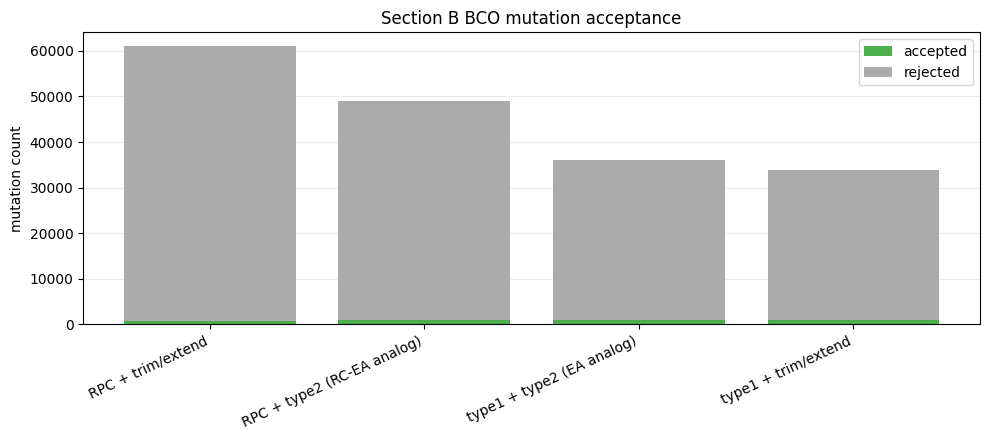

In [ ]:
if final_b_mutation_df.empty:
    print("No Section B mutation stats captured yet; rerun the Section B sweep cell.")
else:
    final_b_mutation_summary = (
        final_b_mutation_df
        .groupby("method", as_index=False)
        .agg(attempted_total=("attempted_total", "sum"),
             accepted_total=("accepted_total", "sum"),
             rejected_total=("rejected_total", "sum"),
             worse_accepted_total=("worse_accepted_total", "sum"),
             runtime_s=("runtime_s", "mean"),
             n_runs=("method", "count"))
    )
    final_b_mutation_summary["acceptance_rate"] = (
        final_b_mutation_summary["accepted_total"] /
        final_b_mutation_summary["attempted_total"].replace(0, np.nan)
    )
    save_table(final_b_mutation_summary, "b_mutation_acceptance_summary",
               subdir=FINAL_RESULTS_SUBDIR)
    display(final_b_mutation_summary.round(3))

    plot_df = final_b_mutation_summary.sort_values("attempted_total", ascending=False)
    xs = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(xs, plot_df["accepted_total"], label="accepted", color="tab:green", alpha=0.85)
    ax.bar(xs, plot_df["rejected_total"], bottom=plot_df["accepted_total"],
           label="rejected", color="tab:gray", alpha=0.65)
    ax.set_xticks(xs)
    ax.set_xticklabels(plot_df["method"], rotation=25, ha="right")
    ax.set_ylabel("mutation count")
    ax.set_title("Section B BCO mutation acceptance")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

### Figure-5 Pareto figure (4 curves)

The 4 ablation variants on one (`ATT`, `RTT`) plot. Down-and-left = better.

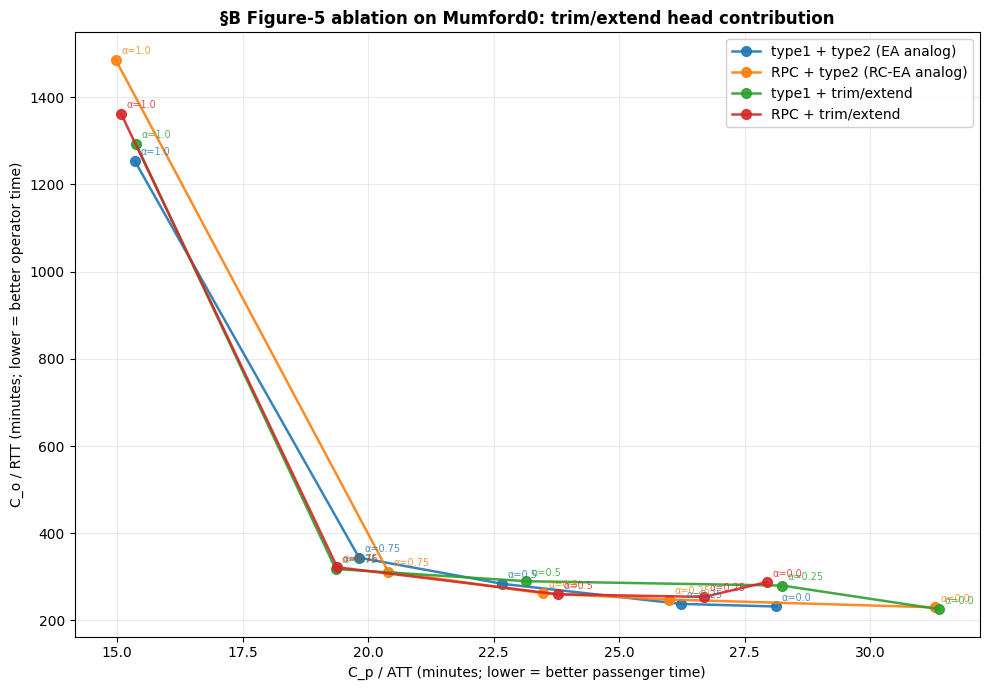

In [ ]:
required_b_cols = {"alpha", "method", "ATT", "RTT"}
if final_b_df.empty or not required_b_cols.issubset(final_b_df.columns):
    print(
        "Section B has no usable rows. Re-run the Section B sweep cell; "
        "if it still fails, inspect the FAILED messages printed above.")
else:
    plot_b_df = final_b_df.dropna(subset=["ATT", "RTT"])
    if plot_b_df.empty:
        print(
            "Section B rows exist, but all ATT/RTT values are NaN. "
            "Re-run the Section B sweep and inspect the FAILED messages above.")
    else:
        fig, ax = plt.subplots(figsize=(10, 7))
        cmap = plt.get_cmap("tab10")
        method_colors = {}
        for i, variant in enumerate(B_ABLATION_VARIANTS):
            label = variant["summary_label"]
            method_colors[label] = cmap(i % 10)
            mdf = plot_b_df[plot_b_df["method"] == label]
            if mdf.empty:
                continue
            agg = mdf.groupby("alpha")[["ATT", "RTT"]].mean().reset_index().sort_values("alpha")
            ax.plot(agg["ATT"], agg["RTT"], marker="o", linestyle="-",
                     linewidth=1.8, markersize=7, label=label,
                     color=method_colors[label], alpha=0.9)
            # Tag the endpoints with the alpha values
            for _, r in agg.iterrows():
                ax.annotate(f"α={r['alpha']}", (r["ATT"], r["RTT"]),
                             xytext=(4, 4), textcoords="offset points",
                             fontsize=7, color=method_colors[label], alpha=0.8)
        ax.set_xlabel("C_p / ATT (minutes; lower = better passenger time)")
        ax.set_ylabel("C_o / RTT (minutes; lower = better operator time)")
        ax.set_title(f"§B Figure-5 ablation on {B_CITY}: trim/extend head contribution",
                      fontweight="bold")
        ax.grid(alpha=0.25)
        ax.legend(loc="best", framealpha=0.9)
        fig.tight_layout()
        plt.show()

## 5. Section C: Trim-grace ablation on Mandl

For "Extend/trim edit-only BCO (all 10 type-5 bees)" on Mandl we sweep
`trim_grace_period in {0, 1, 3, 5, 10}` with `worse_accept` ON. The
trim-grace mechanism (`bee_colony.py`) force-accepts a route-shrinking
mutation as a setup move and shields the bee from cost-based selection
for `trim_grace_period` rounds so a follow-up extend can build on the
trim. Larger values give trims more room to pay off; zero disables the
mechanism.

Plot: cost vs `trim_grace_period`. We expect a U-curve or monotone-down
trend up to some optimum.

In [ ]:
C_CITY = "Mandl"
C_TRIM_GRACE_VALUES = [0, 1, 3, 5, 10]
C_SEED = 0
REUSE_EXISTING_C_SWEEP = True

# We'll target the extend_trim_edit_only variant (all 10 type-5 bees).
C_VARIANT = next(v for v in BCO_VARIANTS if v["key"] == "extend_trim_edit_only")
print(f"§C variant: {C_VARIANT['summary_label']}")
print(f"§C city: {C_CITY}, trim_grace_values: {C_TRIM_GRACE_VALUES}, "
      f"seed={C_SEED}")

In [ ]:
_existing_c_rows = globals().get("final_c_rows", [])
_expected_c_keys = {int(tg) for tg in C_TRIM_GRACE_VALUES}
_existing_c_keys = {
    _int_key(row.get("trim_grace_period"))
    for row in _existing_c_rows
    if _int_key(row.get("trim_grace_period")) is not None
}
_existing_c_rows_ok = (
    len(_existing_c_rows) == len(_expected_c_keys)
    and _existing_c_keys == _expected_c_keys
    and all(_finite_number(row.get("cost")) for row in _existing_c_rows)
)
if (bool(globals().get("REUSE_EXISTING_C_SWEEP", False)) and bool(_existing_c_rows)
        and _existing_c_rows_ok
        and globals().get("final_c_city") == C_CITY
        and globals().get("final_c_init_mode") == globals().get("BENCHMARK_INIT_MODE")):
    final_c_rows = _existing_c_rows
    final_c_mutation_rows = globals().get("final_c_mutation_rows", [])
    print("Reusing existing final_c_rows; "
          "set REUSE_EXISTING_C_SWEEP=False to rerun.")
else:
    if bool(globals().get("REUSE_EXISTING_C_SWEEP", False)) and _existing_c_rows:
        print("Existing final_c_rows do not match the current init mode "
              "or include failed rows; "
              "rerunning Section C.")
    final_c_rows = []
    final_c_mutation_rows = []
    final_c_init_mode = BENCHMARK_INIT_MODE
    final_c_city = C_CITY
    city_to_spec_c = {s["city"]: s for s in BENCHMARK_SPECS}
    spec_c = city_to_spec_c[C_CITY]
    tensors_c, init_routes_c = load_benchmark_graph(spec_c)

    for tg in C_TRIM_GRACE_VALUES:
        print(f"  [§C trim_grace_period={tg}] running...")
        run_start = time.perf_counter()
        try:
            # Build cfg directly to override trim_grace_period -- this is the
            # one knob run_method() doesn't expose explicitly. We also keep
            # worse_accept ON (T0=WORSE_ACCEPT_ON_TEMPERATURE) so the trim-
            # grace mechanism actually engages.
            cfg = build_bco_cfg(
                run_name=f"final_c_tg{tg}_{C_VARIANT['run_name']}",
                n_routes=spec_c["n_routes"],
                min_route_len=spec_c["min_route_len"],
                max_route_len=spec_c["max_route_len"],
                use_neural_bees=C_VARIANT["use_neural_bees"],
                n_type1_bees=C_VARIANT["n_type1_bees"],
                n_type2_bees=C_VARIANT["n_type2_bees"],
                n_type4_bees=C_VARIANT["n_type4_bees"],
                n_type5_bees=C_VARIANT.get("n_type5_bees", 0),
                n_type6_bees=C_VARIANT.get("n_type6_bees", 0),
                n_type7_bees=C_VARIANT.get("n_type7_bees", 0),
                worse_accept_temperature=WORSE_ACCEPT_ON_TEMPERATURE,
                worse_selection_temperature=WORSE_SELECTION_ON_TEMPERATURE,
                trim_grace_period=int(tg),
            )
            cfg.experiment.seed = C_SEED
            _mc_out = {}
            _, metrics, _, _routes, _mc = run_bco(
                cfg, init_routes_c, mutation_counts_out=_mc_out,
                tensors=tensors_c,
                run_name_scope=f"final_c_tg{tg}_")
            runtime_s = time.perf_counter() - run_start
            row = {"city": C_CITY,
                   "trim_grace_period": int(tg),
                   "cost": float(metric_value(metrics, "cost")),
                   "ATT": float(metric_value(metrics, "ATT")),
                   "RTT": float(metric_value(metrics, "RTT")),
                   "d_un": float(metric_value(metrics, "$d_{un}$")),
                   "runtime_s": runtime_s,
                   "init_mode": BENCHMARK_INIT_MODE,
                   "init_method": benchmark_init_label()}
            final_c_rows.append(row)
            _mut_row = _mutation_row(
                "C", C_CITY, float(tg), f"trim_grace={tg}", _mc,
                runtime_s)
            if _mut_row is not None:
                _mut_row["trim_grace_period"] = int(tg)
                final_c_mutation_rows.append(_mut_row)
            print(f"    -> cost={row['cost']:.4f}, ATT={row['ATT']:.2f}, "
                  f"RTT={row['RTT']:.2f}, d_un={row['d_un']:.2f}, "
                  f"time={runtime_s:.1f}s")
        except Exception as exc:
            runtime_s = time.perf_counter() - run_start
            print(f"    FAILED: {exc!r}")
            final_c_rows.append({"city": C_CITY,
                                  "trim_grace_period": int(tg),
                                  "cost": float("nan"),
                                  "ATT": float("nan"), "RTT": float("nan"),
                                  "d_un": float("nan"),
                                  "runtime_s": runtime_s,
                                  "init_mode": BENCHMARK_INIT_MODE,
                                  "init_method": benchmark_init_label()})
        finally:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

if "final_c_mutation_rows" not in globals():
    final_c_mutation_rows = []

final_c_df = pd.DataFrame(final_c_rows)
final_c_mutation_df = pd.DataFrame(final_c_mutation_rows)
save_table(final_c_df, "c_trim_grace_ablation", subdir=FINAL_RESULTS_SUBDIR)
if not final_c_mutation_df.empty:
    save_table(final_c_mutation_df, "c_mutation_acceptance_rows",
               subdir=FINAL_RESULTS_SUBDIR)
display(final_c_df.round(3))

### Section C mutation acceptance by trim grace

Accepted/rejected mutation totals for each `trim_grace_period` value.

In [ ]:
if final_c_mutation_df.empty:
    print("No Section C mutation stats captured yet; rerun the Section C sweep cell.")
else:
    final_c_mutation_summary = final_c_mutation_df[[
        "trim_grace_period", "attempted_total", "accepted_total",
        "rejected_total", "worse_accepted_total",
        "trim_grace_forced_accepts", "trim_grace_protected",
        "acceptance_rate", "runtime_s",
    ]].sort_values("trim_grace_period")
    save_table(final_c_mutation_summary, "c_mutation_acceptance_summary",
               subdir=FINAL_RESULTS_SUBDIR)
    display(final_c_mutation_summary.round(3))

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    xs = np.arange(len(final_c_mutation_summary))
    ax.bar(xs, final_c_mutation_summary["accepted_total"],
           label="accepted", color="tab:green", alpha=0.85)
    ax.bar(xs, final_c_mutation_summary["rejected_total"],
           bottom=final_c_mutation_summary["accepted_total"],
           label="rejected", color="tab:gray", alpha=0.65)
    ax.set_xticks(xs)
    ax.set_xticklabels(final_c_mutation_summary["trim_grace_period"])
    ax.set_xlabel("trim_grace_period")
    ax.set_ylabel("mutation count")
    ax.set_title("Section C BCO mutation acceptance")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

### Trim-grace cost vs `trim_grace_period`

Cost on the y-axis (lower = better) against trim-grace value. A dip
suggests the mechanism helps; flat means no signal at this seed/budget.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(final_c_df["trim_grace_period"], final_c_df["cost"],
         marker="o", linewidth=1.8, markersize=7, color="tab:blue",
         label="cost")
ax.set_xlabel("trim_grace_period")
ax.set_ylabel("cost  (lower = better)")
ax.set_title(f"§C trim-grace ablation on {C_CITY} "
              f"(Extend/trim edit-only, worse_accept ON)",
              fontweight="bold")
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

## 6. Outputs summary

After Run-All the following land in `artifacts/results/final/`
(a dedicated subfolder so this notebook's outputs do not mix with the
other experiment notebooks' tables):

* `benchmark_alpha_rows.csv`           -- §A raw rows (city x alpha x method,
                                          including `runtime_s`).
* `benchmark_runtime_rows.csv`         -- §A run time rows.
* `benchmark_runtime_summary.csv`      -- §A run time summary by method.
* `benchmark_cost_history_rows.csv`    -- §A long-form cost history rows.
* `benchmark_cost_history_summary.csv` -- §A mean cost history curves by method.
* `history_figures/history_<method>.png` -- §A one history figure per method.
* `history_figures/history_summary.png`  -- §A combined history figure.
* `benchmark_mutation_acceptance_rows.csv`    -- §A raw BCO mutation counters.
* `benchmark_mutation_acceptance_summary.csv` -- §A accepted/rejected mutation summary.
* `benchmark_alpha_{0.0,0.5,1.0}.csv`  -- §A per-alpha display tables (one
                                          per alpha, matching Holliday's
                                          Tables 3 / 4 shape).
* `b_pareto_ablation.csv`              -- §B 4-curve Pareto rows.
* `b_mutation_acceptance_rows.csv`     -- §B raw BCO mutation counters.
* `b_mutation_acceptance_summary.csv`  -- §B accepted/rejected mutation summary.
* `c_trim_grace_ablation.csv`          -- §C trim-grace sweep.
* `c_mutation_acceptance_rows.csv`     -- §C raw BCO mutation counters.
* `c_mutation_acceptance_summary.csv`  -- §C accepted/rejected mutation summary.

Non-history figures are shown inline only -- regenerable from the CSVs
after a kernel restart by loading the dataframes with `pd.read_csv` and
re-running the figure cells in isolation.